# Chromosome IV Replicate 1 - Prototype Replication Deconvolution

Inclusion of fix for CG1/DG1 mass. Was previously double counting the mass

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.config import load_default_chrom_configs


In [30]:
config, _ = load_default_chrom_configs()
# Let's start with the fits from the previous good runs,
# these are with 1000 epochs without the delta fix. In
# http://localhost:8888/notebooks/1_Replication_Deconvolution_NHFB_G-H_Updates_Replicate1-Adjusted_for_alpha.ipynb
#
# rn of 0.002623
#
last_known_good_params = {'mu0': 14.926855997420141,
 'delta': 15.130663943754426,
 'sigma0': 6.288228436658738,
 'sigmav': 0.028913623544450304,
 'lambda': 60.0,
 'gamma1': 0.66,
 'gamma2': 1.0,
 'halted': 7.473645129759716e-05,
 'alpha': 22}

config.params_dic.update(last_known_good_params)
config.update_timepoints()
config.calculate_H()
config.params_dic

{'mu0': 14.926855997420141,
 'delta': 15.130663943754426,
 'sigma0': 6.288228436658738,
 'sigmav': 0.028913623544450304,
 'lambda': 60.0,
 'gamma1': 0.66,
 'gamma2': 1.0,
 'halted': 7.473645129759716e-05,
 'alpha': 22}

In [31]:
config.calculate_H()

array([[1.41541432e-01, 1.37121573e-01, 1.28691596e-01, ...,
        9.91133037e-13, 5.73276322e-13, 7.47364513e-05],
       [2.45023011e-02, 3.14811561e-02, 3.91873203e-02, ...,
        1.12849116e-08, 7.38695657e-09, 7.33583097e-05],
       [6.27628278e-04, 1.06583347e-03, 1.75393368e-03, ...,
        1.82551968e-05, 1.35326970e-05, 5.69164804e-05],
       ...,
       [6.59052658e-70, 9.69310126e-69, 1.39264976e-67, ...,
        4.71534698e-03, 5.17952810e-03, 1.85138211e-05],
       [1.22463813e-77, 1.97453335e-76, 3.11291358e-75, ...,
        3.41755859e-04, 3.84208845e-04, 1.71612194e-05],
       [2.55682950e-85, 4.45061187e-84, 7.58207562e-83, ...,
        1.77145512e-03, 1.56911283e-03, 1.46510790e-05]])

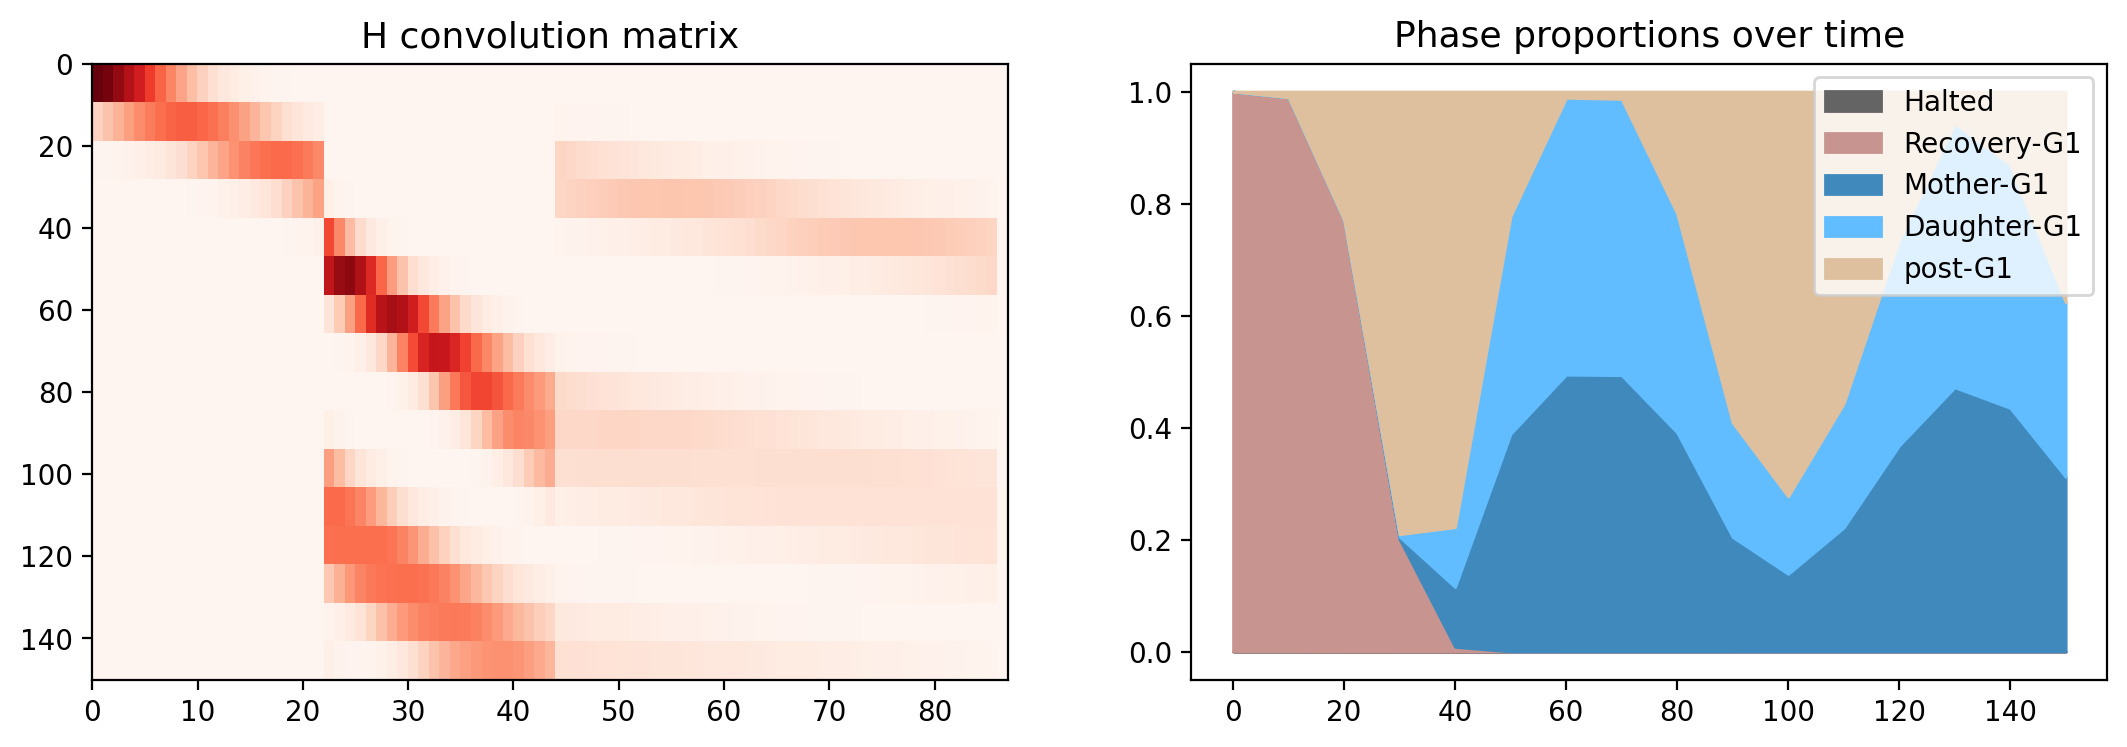

In [34]:
config.plot_H()

In [35]:
real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1, chr=4)

Threshold windows with less than 75% read coverage.


In [37]:
real_deconv1.setup_deconvolution(config)
result = real_deconv1.iterative_deconvolution_updates(20)

Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/702 - 00:00:00.117
100/702 - 00:00:00.251
200/702 - 00:00:00.336
300/702 - 00:00:00.420
400/702 - 00:00:00.514
500/702 - 00:00:00.603
600/702 - 00:00:00.691
700/702 - 00:00:00.772
Iteration completed 00:00:01.560, rn=0.006195305358248816
Iteration 1
0/702 - 00:00:01.563
100/702 - 00:00:01.659
200/702 - 00:00:01.769
300/702 - 00:00:01.851
400/702 - 00:00:01.932
500/702 - 00:00:02.021
600/702 - 00:00:02.108
700/702 - 00:00:02.189
Iteration completed 00:00:02.686, rn=0.00399397770555714
Iteration 2
0/702 - 00:00:02.690
100/702 - 00:00:02.797
200/702 - 00:00:02.890
300/702 - 00:00:02.983
400/702 - 00:00:03.071
500/702 - 00:00:03.155
600/702 - 00:00:03.238
700/702 - 00:00:03.319
Iteration completed 00:00:03.795, rn=0.0033684424559496675
Iteration 3
0/702 - 00:00:03.799
100/702 - 00:00:03.884
200/702 - 00:00:03.967
300/702 - 00:00:04.048
400/702 - 00:00:04.128
500/702 - 00:00:04.209
600/702 - 00:00:04.330
700/702 -

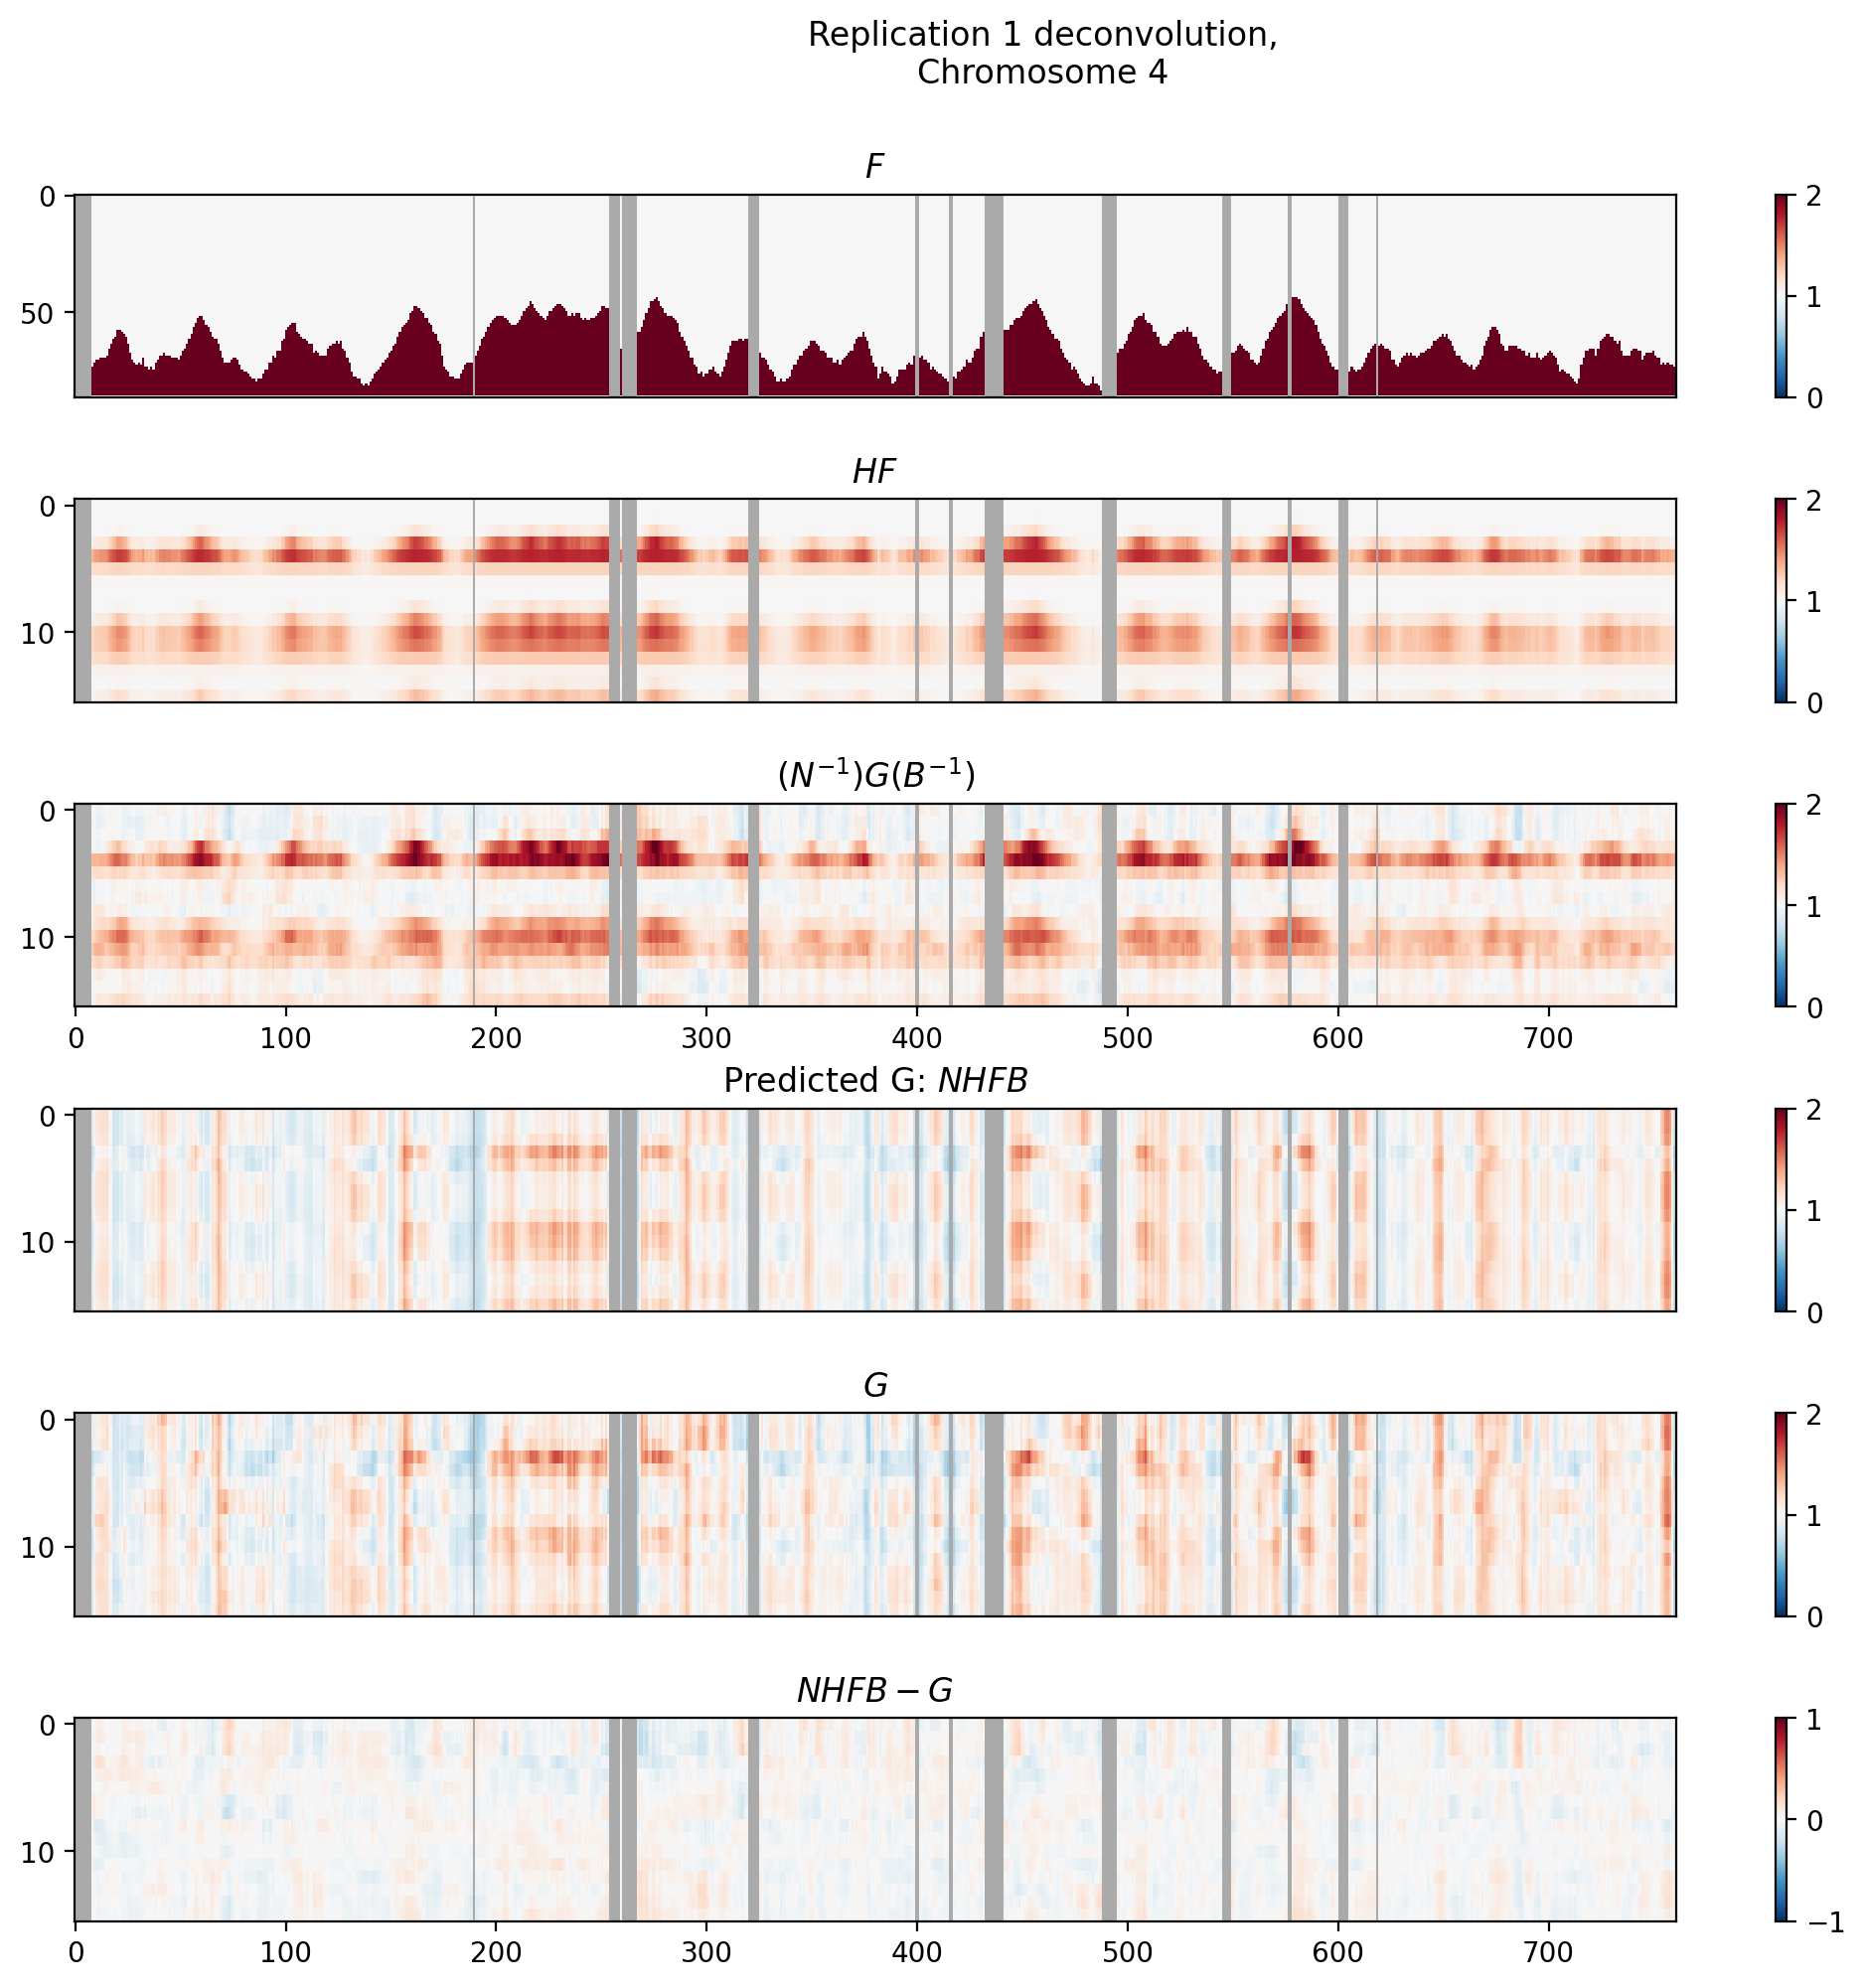

In [39]:
fig = real_deconv1.plot_heatmaps()

3.4000000000000057

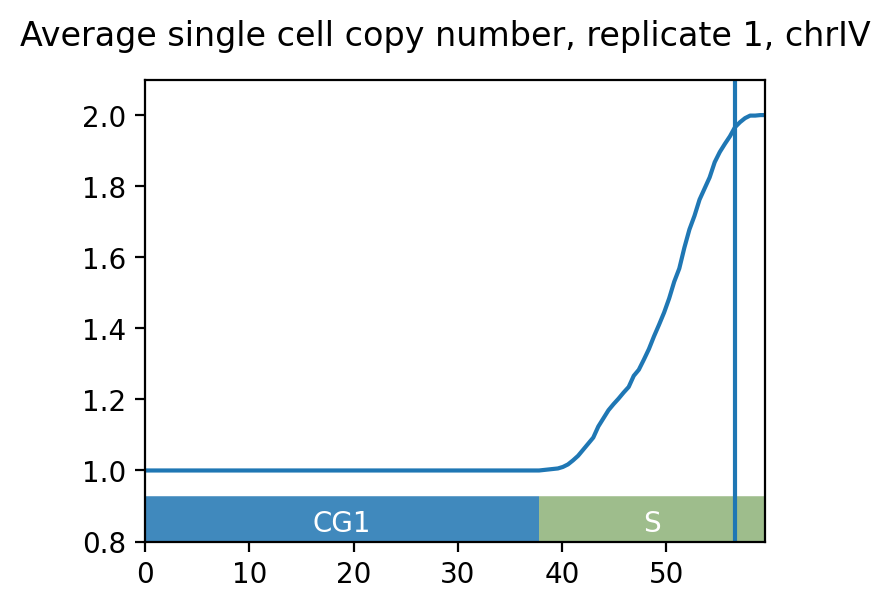

In [40]:
from src.chromatin_model import draw_phase_label_annotations
config = real_deconv1.config

fig = plt.figure(figsize=(4, 3))
t_indices = config.get_Hpositions_for_branch('t')
t_tps = config.get_timepoints_for_branch('t')
plt.plot(t_tps, real_deconv1.F.mean(axis=1)[t_indices])
draw_phase_label_annotations(plt.gca(), config, flip=True, annotations_x=0.85)
plt.xlim(t_tps[0], t_tps[-1])
plt.ylim(0.8, 2.1)
plt.suptitle("Average single cell copy number, replicate 1, chrIV")

# Plot when 95% of the genome has been replicated
x, y = t_tps, real_deconv1.F.mean(axis=1)[t_indices]
g2m_start = t_tps[y > 1.95][0]
plt.axvline(g2m_start)
config.params_dic['lambda'] - g2m_start

array([1.00442364, 1.00347336, 0.97773201, 0.8061213 , 0.66388052,
       0.84322967, 0.99955218, 1.00893152, 0.97884289, 0.85742082,
       0.75599297, 0.76982516, 0.84182678, 0.97059662, 0.99078551,
       0.91119956])

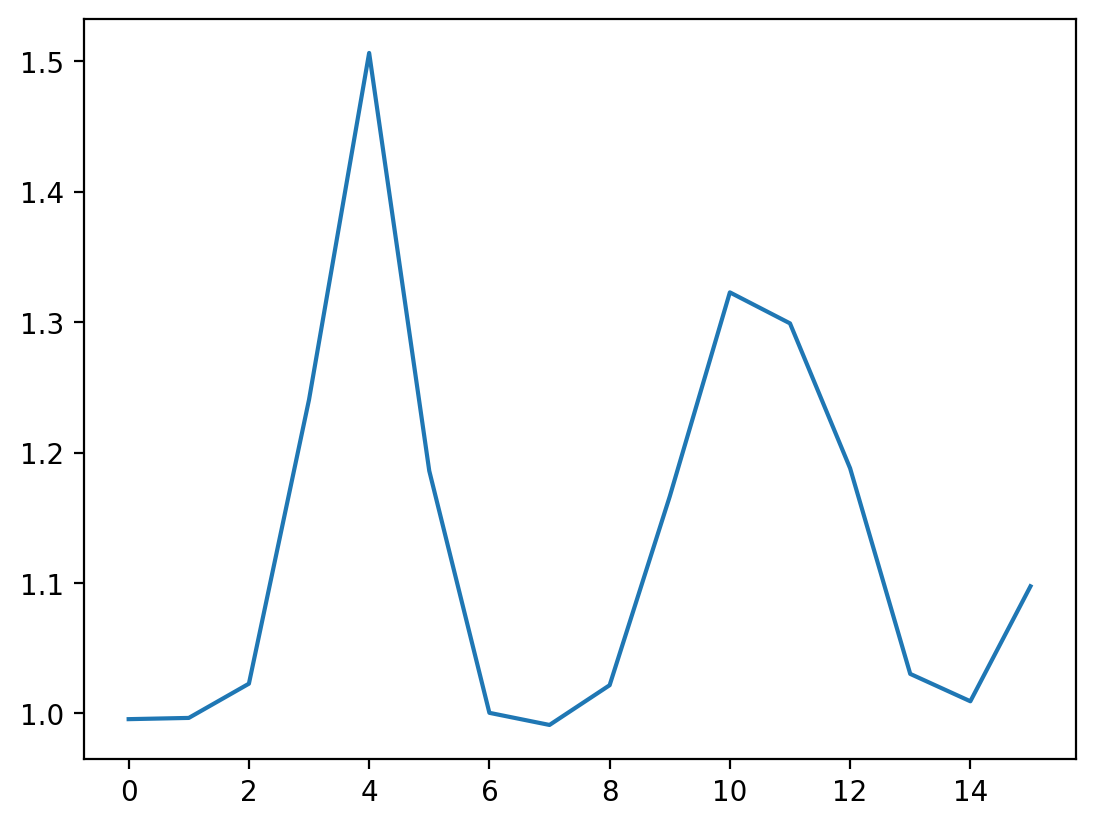

In [44]:
plt.plot(1./np.diag(real_deconv1.N))
np.diag(real_deconv1.N)

In [48]:
real_deconv1.F[:, 0]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 1.])